<a href="https://colab.research.google.com/github/Leeloo-Kikontwe/Codveda_Technologies_Machine_Learning_Internship/blob/main/Task4/Task2_Level2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [113]:
path = '/content/drive/MyDrive/Data_Set_For_Task/Data_Set_For_Task/iris.csv'
df = pd.read_csv(path)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


EXPLORATORY DATA ANALYSIS (EDA) ON THE TRAINING DATASET

In [114]:
df.shape

(150, 5)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [116]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [117]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [118]:
#Check and delete duplicates to avoid skewing the Accuracy and F1 score
df.duplicated().sum()
df.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [119]:
#Check if the target variable is balanced
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


DATA VISUALISATION

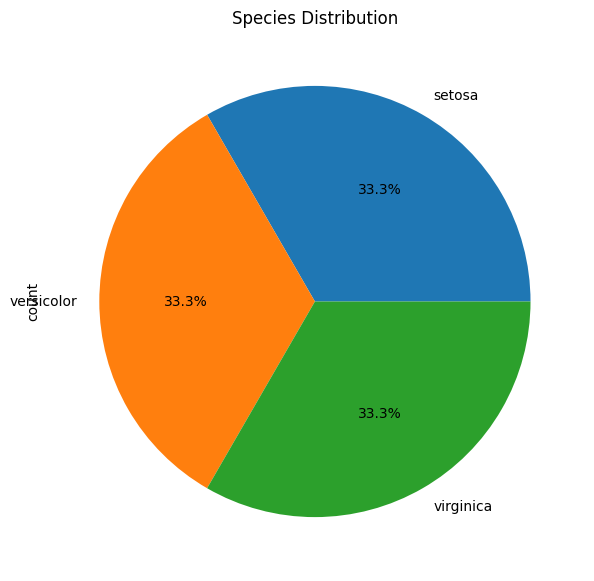

In [120]:
plt.figure(figsize = (7,7))
df['species'].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Species Distribution")
plt.show()

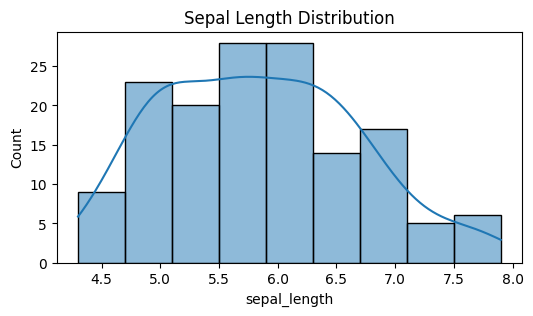

In [121]:
plt.figure(figsize=(6, 3))
sns.histplot(df['sepal_length'], kde=True)
plt.title('Sepal Length Distribution')
plt.show()

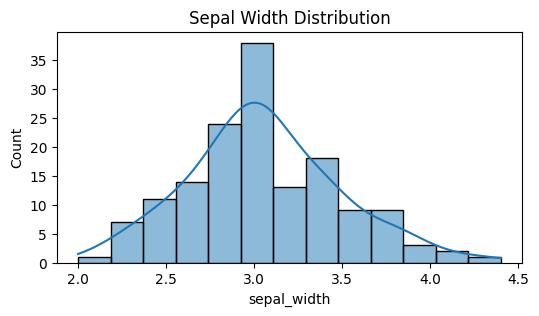

In [122]:
plt.figure(figsize=(6,3))
sns.histplot(df['sepal_width'], kde=True)
plt.title('Sepal Width Distribution')
plt.show()

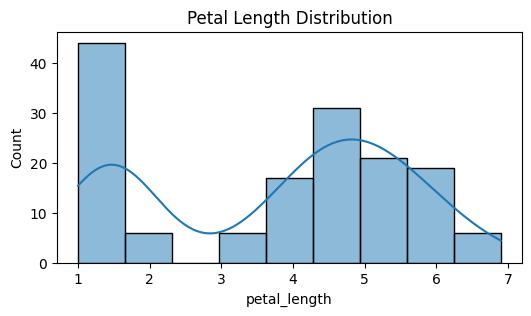

In [123]:
plt.figure(figsize=(6,3))
sns.histplot(df['petal_length'], kde=True)
plt.title('Petal Length Distribution')
plt.show()

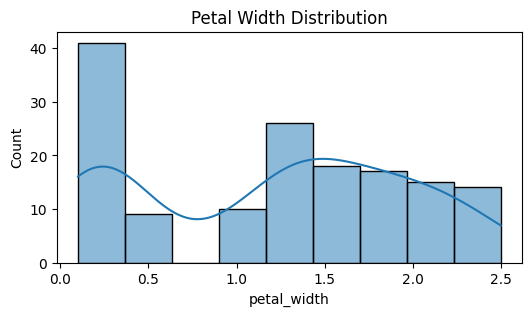

In [124]:
plt.figure(figsize=(6,3))
sns.histplot(df['petal_width'], kde=True)
plt.title('Petal Width Distribution')
plt.show()

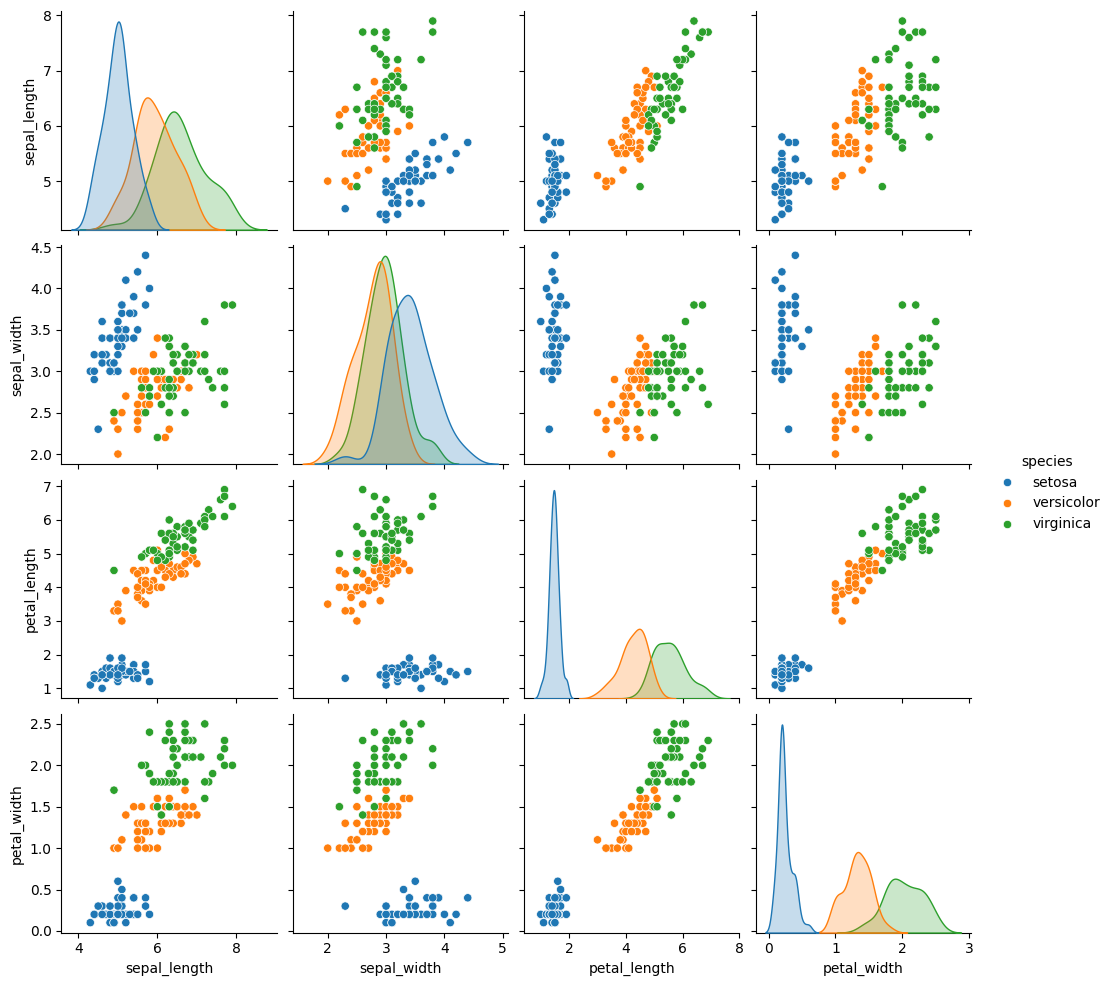

In [125]:
#Pairplot to understand the separation of classes
plt.figure
sns.pairplot(df, hue="species")
plt.show()

ENCODE CATEGORICAL FEATURES

In [126]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


CORRELATION MATRIX

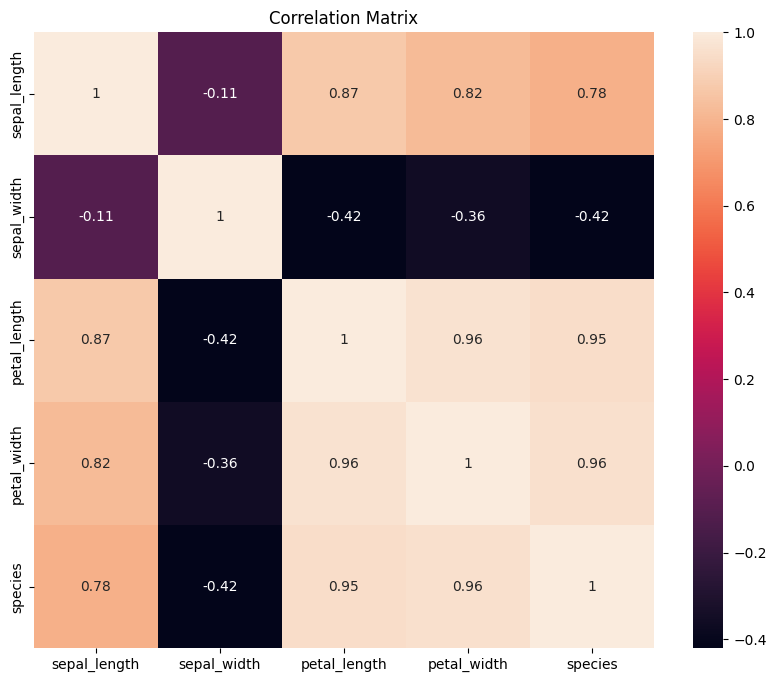

In [127]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot = True)
plt.title("Correlation Matrix")
plt.show()

SEPARATE FEATURES AND TARGET

In [128]:
X = df.drop('species', axis = 1)
Y = df['species']


SPLIT TRAINING AND TESTING SETS

In [129]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2, random_state = 1)

BUILD AND TRAIN THE CLASSIFIER

In [130]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)

DecisionTreeClassifier()

VISUALIZE THE TREE

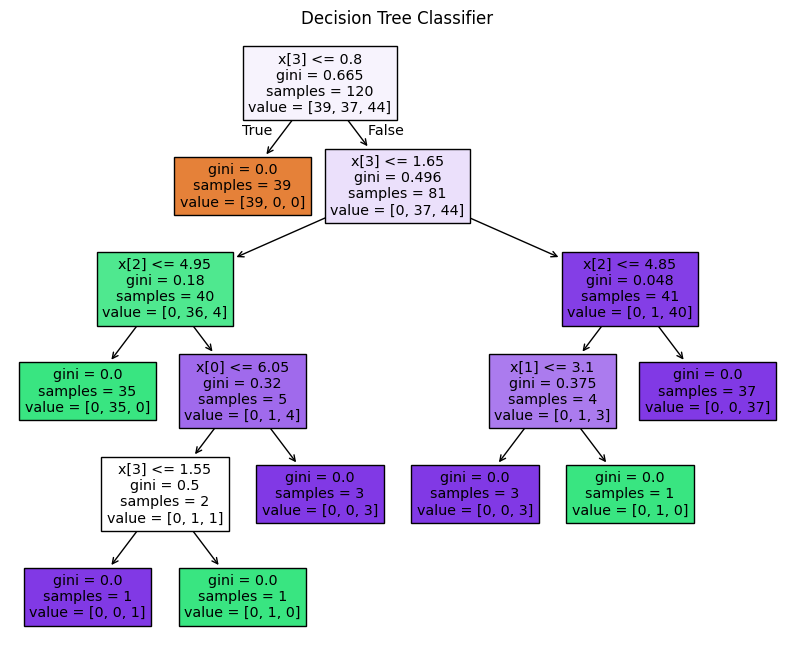

In [131]:
plt.figure(figsize=(10,8))
plot_tree(dtc, filled = True)
plt.title("Decision Tree Classifier")
plt.show()

PRUNE THE TREE TO AVOID OVERFITTING

In [132]:
pruned_dtc = DecisionTreeClassifier(criterion="entropy", ccp_alpha =0.012, min_samples_leaf=5, random_state=1)
pruned_dtc.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.012, criterion='entropy', min_samples_leaf=5,
                       random_state=1)

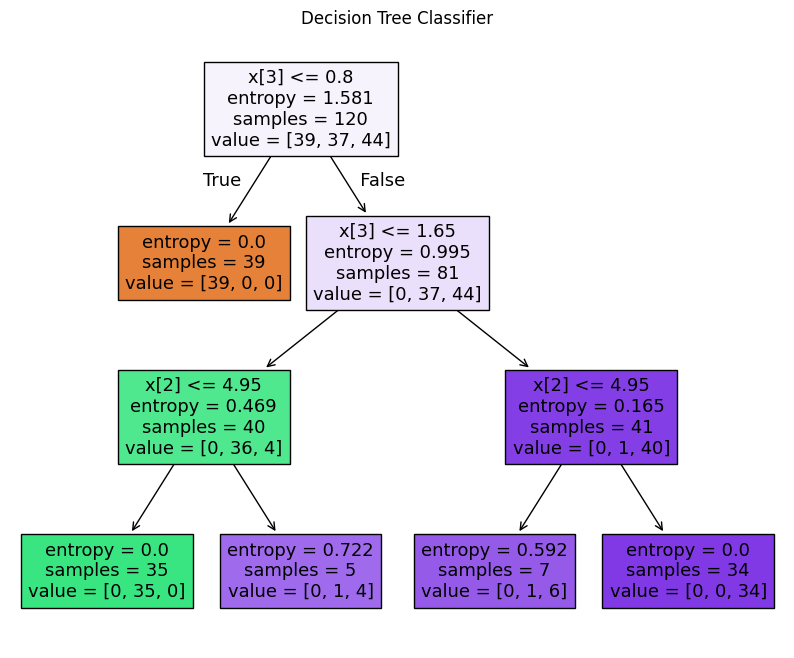

In [133]:
plt.figure(figsize=(10,8))
plot_tree(pruned_dtc, filled = True)
plt.title("Decision Tree Classifier")
plt.show()

PREDICTIONS

In [134]:
y_pred = pruned_dtc.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

EVALUATE THE MODEL

In [137]:
species = ['setosa', 'versicolor','virginica']
print("Classification report: ", classification_report(y_test, y_pred, target_names = species))
print("Accuracy: ", accuracy_score(y_test, y_pred))

Classification report:                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.92      0.96        13
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

Accuracy:  0.9666666666666667
